# Session 2: Working with LLM Coding Agents

## Overview

This assignment explores how large language models function as coding agents within integrated development environments. You'll work with climate emissions data to understand both the capabilities and limitations of LLM-assisted data analysis, with particular attention to how execution environment shapes what's possible.

## Learning Objectives

Through structured exercises with the OWID CO2 dataset, you will:

- **Distinguish** between chat-based LLM interfaces and coding agents with local execution capabilities
- **Develop** fluency in specifying data operations through natural language while understanding the underlying computational patterns
- **Evaluate** the boundary between tasks coding agents handle autonomously versus those requiring human guidance
- **Assess** when programmatic approaches offer advantages over manual analysis methods

## The Execution Environment Question

The same foundation model—Claude Sonnet 4.5, GPT-4, or similar—exhibits markedly different capabilities depending on its execution context. A browser-based chat interface can generate syntactically correct code but lacks the infrastructure to execute, test, and refine it. The model generates a response and moves on.

In contrast, a coding agent operating within VS Code has access to a Python interpreter, your installed packages, the filesystem, and terminal. This enables an iterative cycle: execute code, parse errors or unexpected output, modify the approach, and re-execute. The model maintains context across this loop, accumulating information about what works in your specific environment.

This architectural difference—not model sophistication—determines whether you can request "analyze emissions trends by region" and receive working results, or whether you must manually execute generated code, diagnose failures, and prompt for corrections.

## Working with OWID Climate Data

Our World in Data maintains a comprehensive CO2 emissions dataset with country-level historical data, fuel source breakdowns, and economic indicators. The dataset's accessible format (direct CSV URL, documented schema, standard tabular structure) makes it appropriate for examining how coding agents handle common analytical workflows: filtering, aggregation, reshaping, and visualization.

Your role is to specify analyses in natural language and observe how the coding agent approaches each task. Note what it handles autonomously, where it requires clarification, what libraries it selects, and how it recovers from errors.

---
## Part 0: Setup

Import the necessary libraries for data manipulation and visualization. Request this from your coding agent and observe library selection.

In [68]:
import pandas as pd

# Load the dataset directly from the URL
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
df = pd.read_csv(url)

# Inspect the data
df.head()          # first few rows
df.info()          # column names, dtypes, non-null counts
df.shape           # (rows, columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

(50411, 79)

---
## Part 1: Loading and Initial Exploration

### Task 1.1: Load and Explore

Load the OWID CO2 dataset: `https://github.com/owid/co2-data/raw/master/owid-co2-data.csv`

Request from your coding agent:
1. Load the data using appropriate library
2. Report dimensions (rows × columns)
3. Identify temporal coverage
4. Display sample rows
5. List emissions-related columns

In [69]:
import pandas as pd

# ------------------------------------------------------------------
# 1. Load the data (local cache first, URL fallback)
# ------------------------------------------------------------------
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
local_paths = ["notebooks/data/owid-co2-data.csv", "data/owid-co2-data.csv"]
path = next((p for p in local_paths if __import__("os").path.exists(p)), None)

if path:
    df = pd.read_csv(path)
    print(f"Loaded from local file: {path}")
else:
    df = pd.read_csv(url)
    print("Loaded from URL")

# ------------------------------------------------------------------
# 2. Dimensions
# ------------------------------------------------------------------
print(f"Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")

# ------------------------------------------------------------------
# 3. Temporal coverage
# ------------------------------------------------------------------
print(f"\nTemporal coverage: {df['year'].min()} - {df['year'].max()}")
print(f"Unique years: {df['year'].nunique()}")
print(f"Unique countries/entities: {df['country'].nunique()}")

# ------------------------------------------------------------------
# 4. Sample rows
# ------------------------------------------------------------------
print("\nSample rows (head):")
print(df.head().to_string())

# ------------------------------------------------------------------
# 5. Emissions-related columns
# ------------------------------------------------------------------
emission_keywords = ["co2", "ghg", "methane", "nitrous", "flaring"]
emission_cols = [c for c in df.columns if any(k in c.lower() for k in emission_keywords)]
print(f"\nEmissions-related columns ({len(emission_cols)}):")
for c in emission_cols:
    print(f"  - {c}")

Loaded from local file: data/owid-co2-data.csv
Dimensions: 50,411 rows x 79 columns

Temporal coverage: 1750 - 2024
Unique years: 275
Unique countries/entities: 254

Sample rows (head):
       country  year iso_code  population  gdp  cement_co2  cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  co2_including_luc  co2_including_luc_growth_abs  co2_including_luc_growth_prct  co2_including_luc_per_capita  co2_including_luc_per_gdp  co2_including_luc_per_unit_energy  co2_per_capita  co2_per_gdp  co2_per_unit_energy  coal_co2  coal_co2_per_capita  consumption_co2  consumption_co2_per_capita  consumption_co2_per_gdp  cumulative_cement_co2  cumulative_co2  cumulative_co2_including_luc  cumulative_coal_co2  cumulative_flaring_co2  cumulative_gas_co2  cumulative_luc_co2  cumulative_oil_co2  cumulative_other_co2  energy_per_capita  energy_per_gdp  flaring_co2  flaring_co2_per_capita  gas_co2  gas_co2_per_capita  ghg_excluding_lucf_per_capita  ghg_per_capita  land_use_change_co2  land_

### Task 1.2: Filtering and Ranking

Identify the top 5 CO2 emitting countries (not aggregate regions) in 2022.

**Note:** Dataset includes aggregate entities (World, continents, income groups). The coding agent needs to distinguish actual countries - observe whether it infers this from ISO codes or requires explicit guidance.

In [70]:
# Task 1.2 - Your code here
# Filter to real countries only: they have ISO codes; aggregates do not
countries = df[df["iso_code"].notna()]

# 2022, sorted by total CO2 emissions descending
top5 = (
    countries[countries["year"] == 2022]
    .dropna(subset=["co2"])
    .nlargest(5, "co2")
    [["country", "co2"]]
    .reset_index(drop=True)
)

print(top5)

         country        co2
0          China  11711.808
1  United States   5055.403
2          India   2831.132
3         Russia   1675.461
4          Japan   1029.645


### Task 1.3: Time Series Visualization

Create a line chart showing CO2 emissions trajectories for the top 5 emitters (1990-2022).

**Expected observation:** China overtaking US around 2005-2006.

**What to notice:** Does the agent select appropriate visualization library? Handle missing data? Create informative labels?

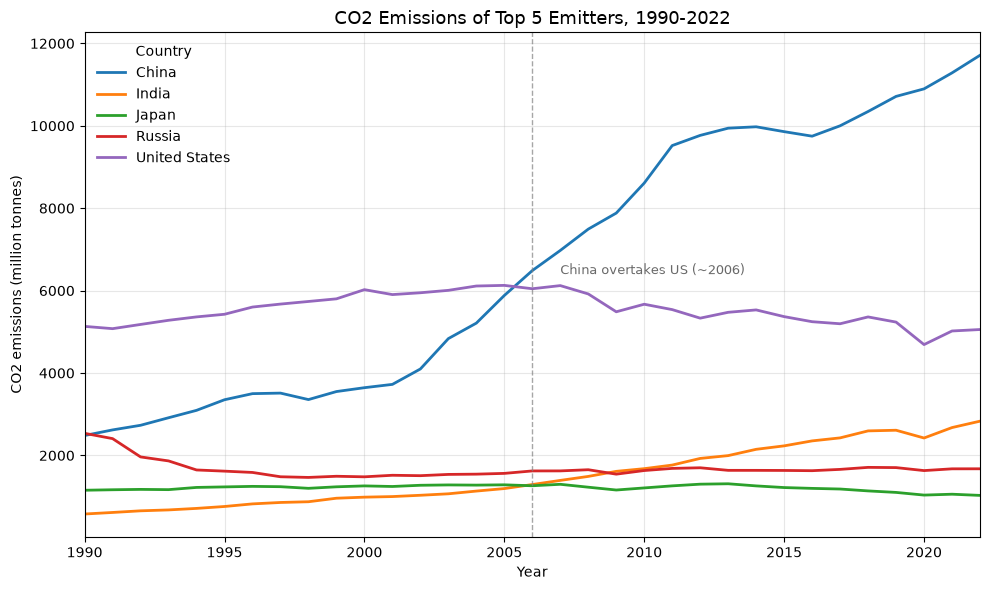

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

# Build on df from Task 1.1; re-create top-5 list from Task 1.2
top5 = ["China", "United States", "India", "Russia", "Japan"]

# Filter: top-5 countries, 1990-2022, valid co2 values
plot_df = df[
    df["country"].isin(top5)
    & df["year"].between(1990, 2022)
    & df["co2"].notna()
]

# Pivot to wide format: rows = year, cols = country
pivot = plot_df.pivot(index="year", columns="country", values="co2")

# ------------------------------------------------------------------
# Line chart
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(ax=ax, linewidth=2)

# China's overtaking of the US in 2006
ox_year = 2006
ax.axvline(ox_year, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.annotate("China overtakes US (~2006)",
            xy=(ox_year, 6400), xytext=(ox_year + 1, 6400),
            fontsize=9, color="dimgrey")

ax.set_title("CO2 Emissions of Top 5 Emitters, 1990-2022", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.set_xlim(1990, 2022)
ax.grid(True, alpha=0.3)
ax.legend(title="Country", frameon=False)

plt.tight_layout()
plt.show()

### Task 1.4: Compositional Analysis

For the top 5 countries in 2022, visualize emissions breakdown by source:
- Coal (`coal_co2`)
- Oil (`oil_co2`)
- Gas (`gas_co2`)  
- Cement (`cement_co2`)

Use a stacked bar chart or equivalent compositional visualization.

**Data reshaping challenge:** This requires pivoting from wide format (separate columns per source) to long format (source as variable). The coding agent should handle this transformation autonomously.

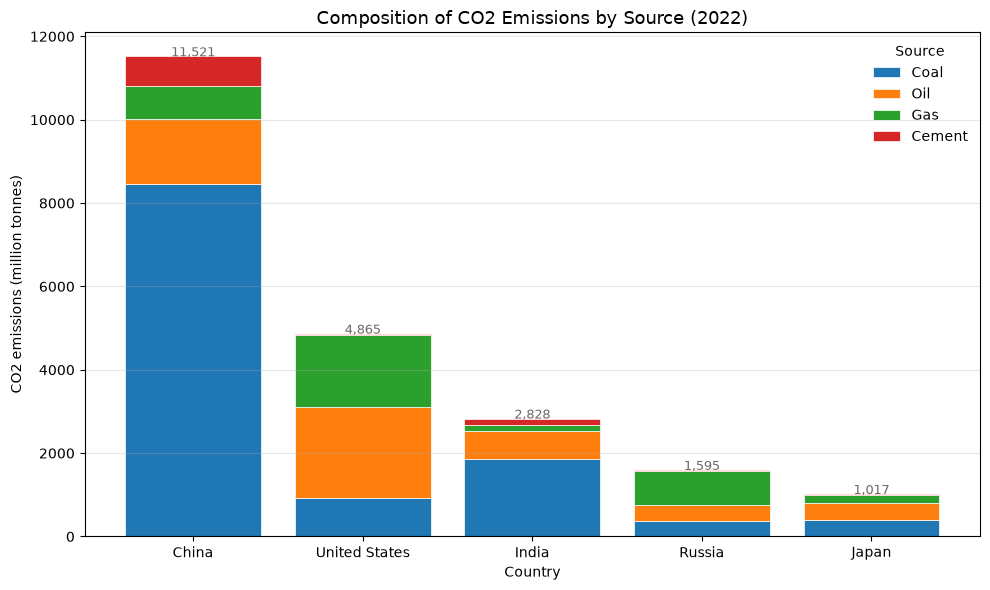

In [73]:
import matplotlib.pyplot as plt

# Top-5 countries (from Task 1.2)
top5 = ["China", "United States", "India", "Russia", "Japan"]

# Fuel-source columns — NOTE: these are per-Mt (same units as co2)
source_cols = ["coal_co2", "oil_co2", "gas_co2", "cement_co2"]

# Wide -> narrow: pivot each country's 2022 row, keeping the 4 sources
comp = (
    df[df["country"].isin(top5) & (df["year"] == 2022)]
    .set_index("country")[source_cols]
    .loc[top5]                      # enforce top-5 order
)

# Human-readable labels for the legend
source_labels = {
    "coal_co2": "Coal",
    "oil_co2": "Oil",
    "gas_co2": "Gas",
    "cement_co2": "Cement",
}

# ------------------------------------------------------------------
# Stacked bar chart
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
bottom = [0] * len(comp)

for col in source_cols:
    ax.bar(comp.index, comp[col], bottom=bottom,
           label=source_labels[col], edgecolor="white", linewidth=0.5)
    bottom = [b + v for b, v in zip(bottom, comp[col])]

# Value labels on each bar
for i, country in enumerate(comp.index):
    ax.text(i, bottom[i] + 1.5, f"{bottom[i]:,.0f}",
            ha="center", fontsize=9, color="dimgrey")

ax.set_title("Composition of CO2 Emissions by Source (2022)", fontsize=13)
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.set_xlabel("Country")
ax.legend(title="Source", frameon=False)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [56]:
# Task 1.4 - Your code here


---
## Part 2: Advanced Operations

### Task 2.1: Aggregation by Grouping Variable

Calculate average per capita CO2 emissions by continent for 2022. Return results sorted descending.

**Key operation:** This requires `groupby()` with aggregation. The coding agent should:
1. Identify the continent variable in the schema
2. Filter to 2022 and valid per capita values
3. Compute mean by group
4. Handle missing data appropriately

In [74]:
continents = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]

# Continent aggregate rows carry their own population-weighted per-capita
result = (
    df[(df["country"].isin(continents)) & (df["year"] == 2022)]
    .sort_values("co2_per_capita", ascending=False)
    .set_index("country")
    [["co2_per_capita", "co2", "population"]]
)
print(result)

               co2_per_capita        co2    population
country                                               
North America          10.390   6236.024  6.043563e+08
Oceania                 9.679    433.490  4.504968e+07
Europe                  6.813   5095.635  7.483143e+08
Asia                    4.685  22237.812  4.746330e+09
South America           2.557   1100.028  4.304928e+08
Africa                  1.010   1459.114  1.445863e+09


In [57]:
# Task 2.1 - Your code here



### Task 2.2: Percentage Change Calculation

Identify countries with:
1. Five largest emission increases (2010→2022, percentage)
2. Five largest emission decreases (2010→2022, percentage)

Visualize both groups for comparison.

**Complexity:** Requires joining data across years, computing percentage change, handling countries with missing baseline or endpoint data. Observe error handling strategies.

### Task 2.3: Faceted Visualization

Create small multiples showing per capita CO2 trends (1990-2022) with one panel per continent.

**Visualization technique:** Faceting/small multiples allow pattern comparison across categories. The coding agent should select appropriate library (Altair, matplotlib with subplots, etc.) and configure layout.

=== FIVE LARGEST INCREASES (2010→2022) ===
year       iso_code   2010    2022  pct_change
country                                       
Laos            LAO  3.001  22.549  651.382872
Tajikistan      TJK  2.535  10.521  315.029586
Cambodia        KHM  5.067  20.865  311.782120
Nepal           NPL  4.828  17.609  264.726595
Mozambique      MOZ  2.638   9.296  252.388173

=== FIVE LARGEST DECREASES (2010→2022) ===
year    iso_code     2010     2022  pct_change
country                                       
Aruba        ABW    2.506    0.888  -64.565044
Yemen        YEM   25.818   10.404  -59.702533
Ukraine      UKR  294.366  143.040  -51.407432
Syria        SYR   62.057   31.423  -49.364294
Curacao      CUW    4.034    2.209  -45.240456


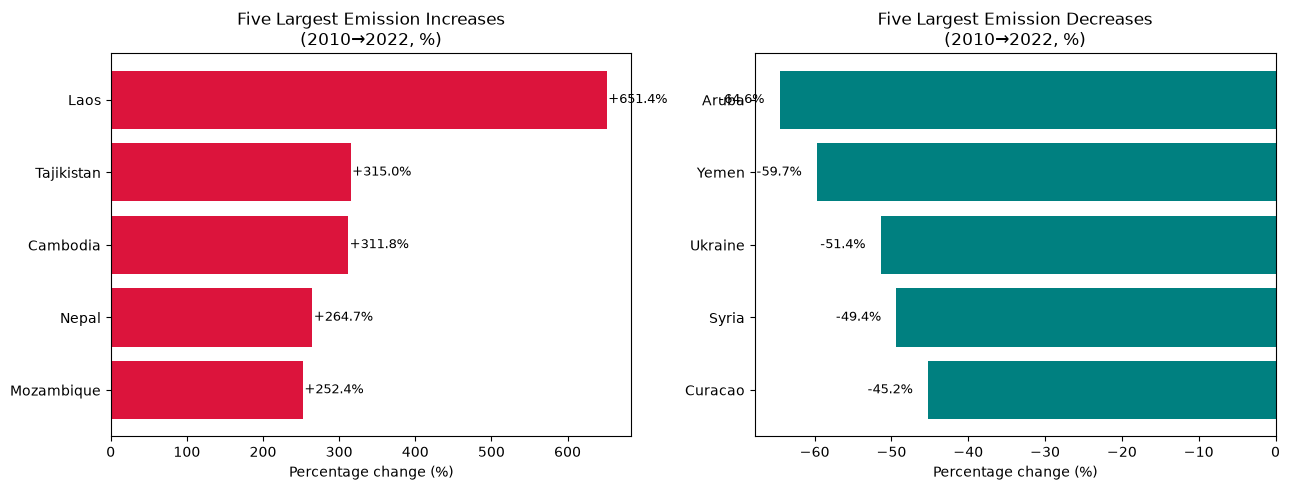

In [78]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Compute percentage change 2010 -> 2022 for all real countries
# ------------------------------------------------------------------
years = df[df["year"].isin([2010, 2022])].copy()

# Pivot so we get per-country 2010 and 2022 co2 side by side
pivot = years.pivot_table(index="country", columns="year", values="co2")

# Only keep real countries (have ISO code) with BOTH years present
iso = df.drop_duplicates("country").set_index("country")["iso_code"]
pct = pivot.assign(iso_code=iso).dropna(subset=["iso_code", 2010, 2022]).copy()
#        ^^^^^^^^                                 ^^^^^^^^^
#        now matches                                  now matches

# Percentage change formula: (new - old) / old * 100
pct["pct_change"] = (pct[2022] - pct[2010]) / pct[2010] * 100
pct["abs_change"] = pct[2022] - pct[2010]

# Optional: restrict to countries with meaningful 2010 emissions
# to avoid tiny-baseline distortions dominating the ranking
pct = pct[pct[2010] >= 1.0]

# ------------------------------------------------------------------
# 2. Top 5 increases / decreases
# ------------------------------------------------------------------
top_increases = pct.nlargest(5, "pct_change")
top_decreases = pct.nsmallest(5, "pct_change")

print("=== FIVE LARGEST INCREASES (2010→2022) ===")
print(top_increases[["iso_code", 2010, 2022, "pct_change"]])

print("\n=== FIVE LARGEST DECREASES (2010→2022) ===")
print(top_decreases[["iso_code", 2010, 2022, "pct_change"]])

# ------------------------------------------------------------------
# 3. Visualization: two horizontal bar charts side by side
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

increases = top_increases.iloc[::-1]      # reverse so largest is on top
axes[0].barh(increases.index, increases["pct_change"], color="crimson")
axes[0].set_title("Five Largest Emission Increases\n(2010→2022, %)")
axes[0].set_xlabel("Percentage change (%)")
for i, v in enumerate(increases["pct_change"]):
    axes[0].text(v + 2, i, f"{v:+.1f}%", va="center", fontsize=9)

decreases = top_decreases.iloc[::-1]
axes[1].barh(decreases.index, decreases["pct_change"], color="teal")
axes[1].set_title("Five Largest Emission Decreases\n(2010→2022, %)")
axes[1].set_xlabel("Percentage change (%)")
for i, v in enumerate(decreases["pct_change"]):
    axes[1].text(v - 2, i, f"{v:+.1f}%", va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.show()

In [77]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Compute percentage change 2010 -> 2022 for all real countries
# ------------------------------------------------------------------
years = df[df["year"].isin([2010, 2022])].copy()

# Pivot so we get per-country 2010 and 2022 co2 side by side
pivot = years.pivot_table(index="country", columns="year", values="co2")

# Only keep real countries (have ISO code) with BOTH years present
iso = df.drop_duplicates("country").set_index("country")["iso_code"]
pct = pivot.assign(iso=iso).dropna(subset=["iso_code", 2010, 2022]).copy()

# Percentage change formula: (new - old) / old * 100
pct["pct_change"] = (pct[2022] - pct[2010]) / pct[2010] * 100
pct["abs_change"] = pct[2022] - pct[2010]

# Optional: restrict to countries with meaningful 2010 emissions
# (e.g., >= 1 Mt) to avoid tiny-baseline distortions dominating
pct = pct[pct[2010] >= 1.0]      # comment out to include tiny baseline countries

# ------------------------------------------------------------------
# 2. Top 5 increases / decreases
# ------------------------------------------------------------------
top_increases = pct.nlargest(5, "pct_change")
top_decreases = pct.nsmallest(5, "pct_change")

print("=== FIVE LARGEST INCREASES (2010→2022) ===")
print(top_increases[["iso", 2010, 2022, "pct_change"]])

print("\n=== FIVE LARGEST DECREASES (2010→2022) ===")
print(top_decreases[["iso", 2010, 2022, "pct_change"]])

# ------------------------------------------------------------------
# 3. Visualization: two horizontal bar charts side by side
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

increases = top_increases.iloc[::-1]      # reverse so largest is on top
axes[0].barh(increases.index, increases["pct_change"], color="crimson")
axes[0].set_title("Five Largest Emission Increases\n(2010→2022, %)")
axes[0].set_xlabel("Percentage change (%)")

for i, v in enumerate(increases["pct_change"]):
    axes[0].text(v + 2, i, f"{v:+.1f}%", va="center", fontsize=9)

decreases = top_decreases.iloc[::-1]
axes[1].barh(decreases.index, decreases["pct_change"], color="teal")
axes[1].set_title("Five Largest Emission Decreases\n(2010→2022, %)")
axes[1].set_xlabel("Percentage change (%)")

for i, v in enumerate(decreases["pct_change"]):
    axes[1].text(v - 2, i, f"{v:+.1f}%", va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.show()

KeyError: ['iso_code']

In [59]:
# Task 2.3 - Your code here



---
## Part 3: Independent Analysis

### Task 3.1: Design and Execute Analysis

Select ONE question and complete the analysis:

**Option A:** Emissions Intensity Improvements
- Identify countries with largest reductions in CO2 per unit GDP (2000-2022)
- Visualize as efficiency gains

**Option B:** Coal Transition Analysis
- Find countries that significantly reduced coal's share of total emissions (2010-2022)
- Show before/after fuel composition

**Option C:** Population-Emissions Relationship
- Analyze correlation between population growth and emissions growth
- Create annotated scatter plot highlighting outliers

**Deliverables:**
- Working code that executes without errors
- At least one publication-quality visualization
- Interpretation of findings and limitations

### My Analysis:

**Question I'm investigating:**

[Describe your chosen question here]

In [60]:
# Your analysis code here



### Analysis Summary

**Research question:**

**Methodology:**

**Key findings:**

**Limitations and caveats:**

---
## Part 4: Critical Reflection

### Evaluating Coding Agent Performance

Analyze your experience across the preceding exercises:

**1. Autonomous Completion Rate**  
What proportion of tasks executed correctly on first attempt? Where did the agent require clarification, correction, or multiple iterations?

**2. Error Recovery Patterns**  
When code failed, document the agent's diagnostic approach. Did it parse error messages effectively? Make appropriate modifications? Or require explicit guidance to identify the problem?

**3. Technical Choices**  
Examine the agent's library selections (ibis, pandas, polars) and data manipulation strategies. Were choices appropriate for the data scale and operation complexity? Could you identify more efficient approaches?

**4. Edge Case Handling**  
How did the agent address missing data, type inconsistencies, or ambiguous specifications? What assumptions did it make, and were they reasonable?

**5. Conceptual Transfer**  
You've worked with groupby aggregation, wide-to-long reshaping, faceted visualization, and percentage change calculations. Can you now explain these patterns to a colleague and recognize when to apply them, independent of specific syntax?

**6. Execution Environment Dependency**  
Which tasks could a browser-based LLM complete versus those requiring local execution? Where precisely does the boundary lie?

**7. Workflow Integration**  
How does this approach to exploratory analysis compare to your current methods? Where do you see coding agents adding value in professional contexts? Where do they introduce friction or uncertainty?

**Your analysis:**

1. 

2. 

3. 

4. 

5. 

6. 

7. 

---
## Submission Guidelines

**Required Components:**
1. Executed notebook with all code cells producing correct output
2. Completed reflection responses in Part 4
3. Original analysis from Part 3 with supporting visualization

**Evaluation Framework:**

*Technical Execution (30%)*  
Code quality, error handling, appropriate method selection, efficient data operations

*Conceptual Understanding (30%)*  
Demonstrated grasp of data manipulation patterns and coding agent capabilities through reflection responses

*Visualization Design (20%)*  
Clear, accurate, publication-ready graphics with appropriate encodings

*Analytical Depth (20%)*  
Part 3 investigation shows thoughtful problem formulation, appropriate scope, and clear interpretation

The assessment focuses on your understanding of how coding agents operate within execution environments and when to rely on versus scrutinize their output—not on independent Python proficiency.